In [1]:
import numpy as np
import scipy as sp
import scipy.fft
from matplotlib import pyplot as plt

# Projeto 3 - Sinais e Sistemas em Tempo Discreto - 2024/01
# Identificação
## Nome: Andreza Rodrigues Costa
## Matrícula: 180074474

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [26]:
#Código das funções utilizadas.

# Definir a função ret(x)
def ret(x):
    if abs(x) > 0.5:
        return 0
    elif abs(x) == 0.5:
        return 0.5
    else:
        return 1

# Vetorizar a função ret(x) para que possa ser aplicada em arrays numpy
ret_vectorized = np.vectorize(ret)

# Definir o sinal x(t) utilizando a função ret(x)
def x(t):
    return 8 * ret_vectorized(t)

# Transformada de Fourier contínua (analítica)
def X_cont(f):
    return 8 * np.sinc(f)


# Implementação da DFT manualmente
def DFT(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

# Implementação da IDFT manualmente
def IDFT(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)
    return x / N

# Função para identificar as frequências de pico usando FFT
def identificar_frequencias(signal, sample_rate):
    N = len(signal)
    yf = scipy.fft.fft(signal)
    xf = np.fft.fftfreq(N, 1 / sample_rate)

    # Selecionar apenas a parte positiva do espectro
    idx = np.where(xf >= 0)
    xf = xf[idx]
    yf = np.abs(yf[idx])

    # Identificar as duas frequências dominantes
    indices = np.argsort(yf)[-2:]  # Pegando os índices das duas maiores amplitudes
    frequencias = xf[indices]
    return sorted(frequencias)

# Função para mapear a frequência identificada para a frequência mais próxima esperada
def mapear_frequencia(freq, frequencias_esperadas):
    return min(frequencias_esperadas, key=lambda x: abs(x - freq))

# Função para decodificar o sinal
def decodificar_sinal(signal, sample_rate):
    freqs = identificar_frequencias(signal, sample_rate)
    linha_freq = mapear_frequencia(min(freqs), linhas_freq)
    coluna_freq = mapear_frequencia(max(freqs), colunas_freq)
    
    print(f"Sinal: {signal[:10]}... Frequências identificadas: {freqs} -> Mapeadas: [{linha_freq}, {coluna_freq}]")

    linha_idx = np.argmin([abs(linha_freq - f) for f in linhas_freq])
    coluna_idx = np.argmin([abs(coluna_freq - f) for f in colunas_freq])

    return teclas[linha_idx, coluna_idx]


# Questão 1

Considere um sinal $x\left(t\right) = 8 \cdot \text{ret}\left(t\right)$, onde:

$$ \begin{align}
	\text{ret}\left(x\right) = \begin{cases}
                               0 & \text{se} ~~ \left|x\right| > \frac{1}{2} \\
															 \frac{1}{2} & \text{se} ~~ \left|x\right| = \frac{1}{2} \\
															 1 & \text{se} ~~ \left|x\right| < \frac{1}{2} \\
                             \end{cases}
\end{align}                             
$$

Considere que o sinal será amostrado a uma taxa $T = \frac{1}{8}$ s, e que queremos uma resolução na frequência de $f_0 = \frac{1}{4}$ Hz.



## Questão 1a (1.0 ponto)

Obtenha o sinal $x\left[n\right]$, como uma amostragem de $x\left(t\right)$ .

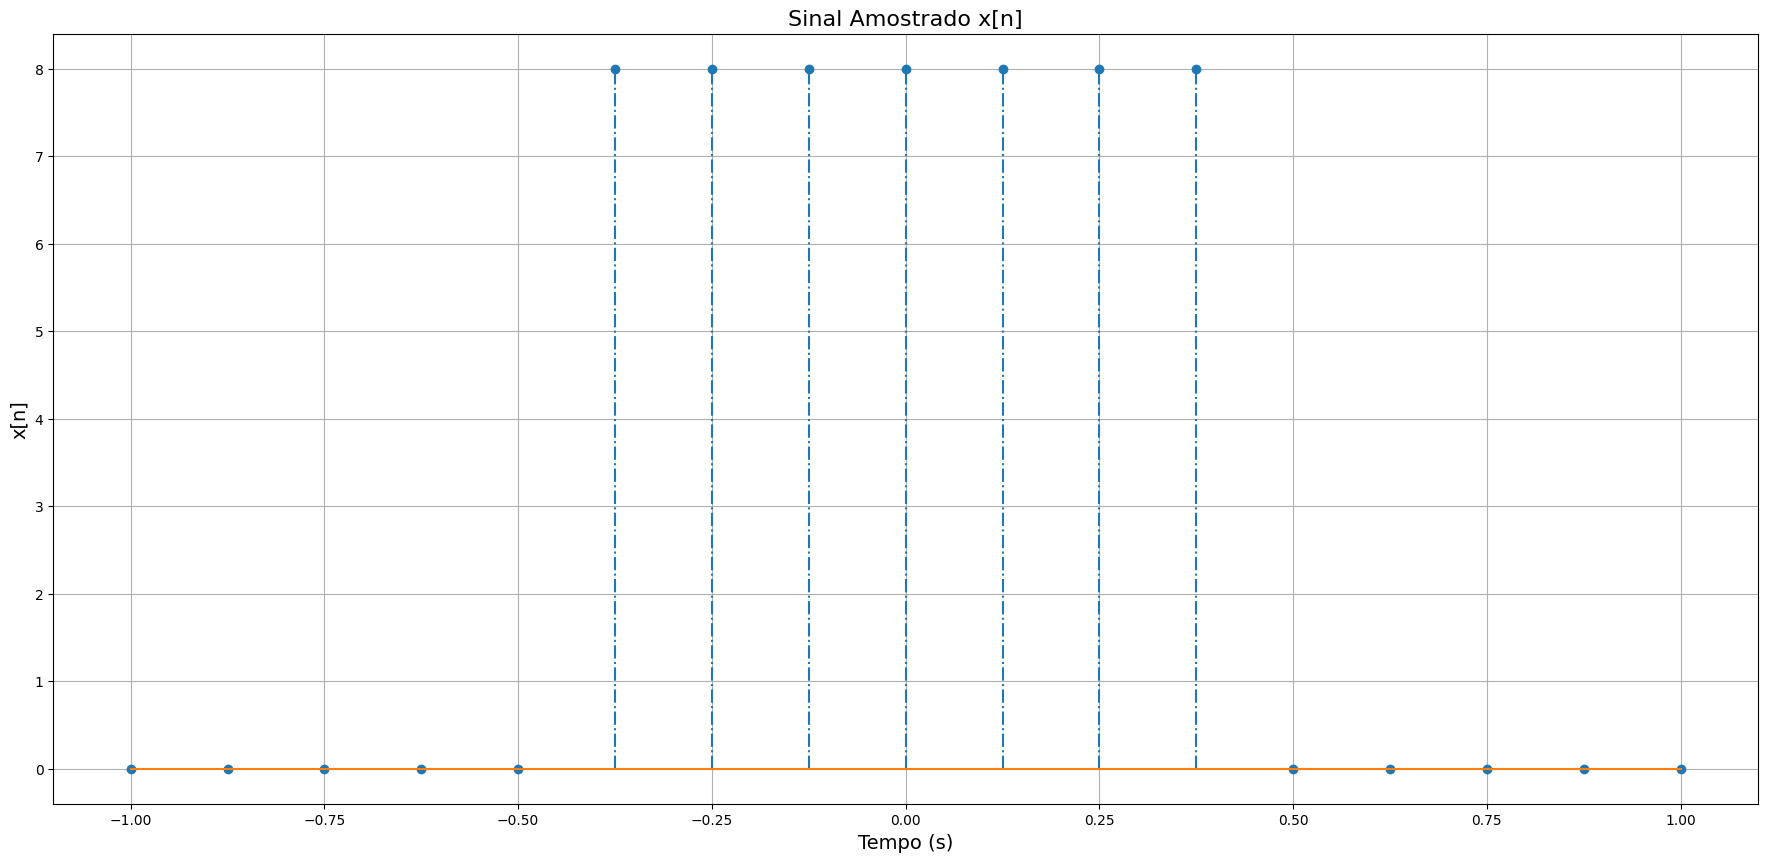

In [11]:
# Resposta da questão 1a

# Taxa de amostragem T = 1/8 s
T = 1/8

# Definir o tempo de amostragem
t = np.arange(-1, 1 + T, T)  # inclui 1, adicionando T para garantir a inclusão do ponto final

# Obter as amostras do sinal x(t)
x_samples = x(t)

# Configurar o tamanho da figura
plt.figure(figsize=(22,10))

# Plotar o sinal amostrado
plt.stem(t, x_samples, linefmt='-.', markerfmt='o', basefmt='-')
plt.xlabel('Tempo (s)', fontsize=14)
plt.ylabel('x[n]', fontsize=14)
plt.title('Sinal Amostrado x[n]', fontsize=16)
plt.grid(True)
plt.show()


## Questão 1b (1.0 ponto)

Compare a transformada de Fourier real do sinal $x\left(t\right)$ com a Transformada Discreta de Fourier obtida a partir de $x\left[n\right]$ .

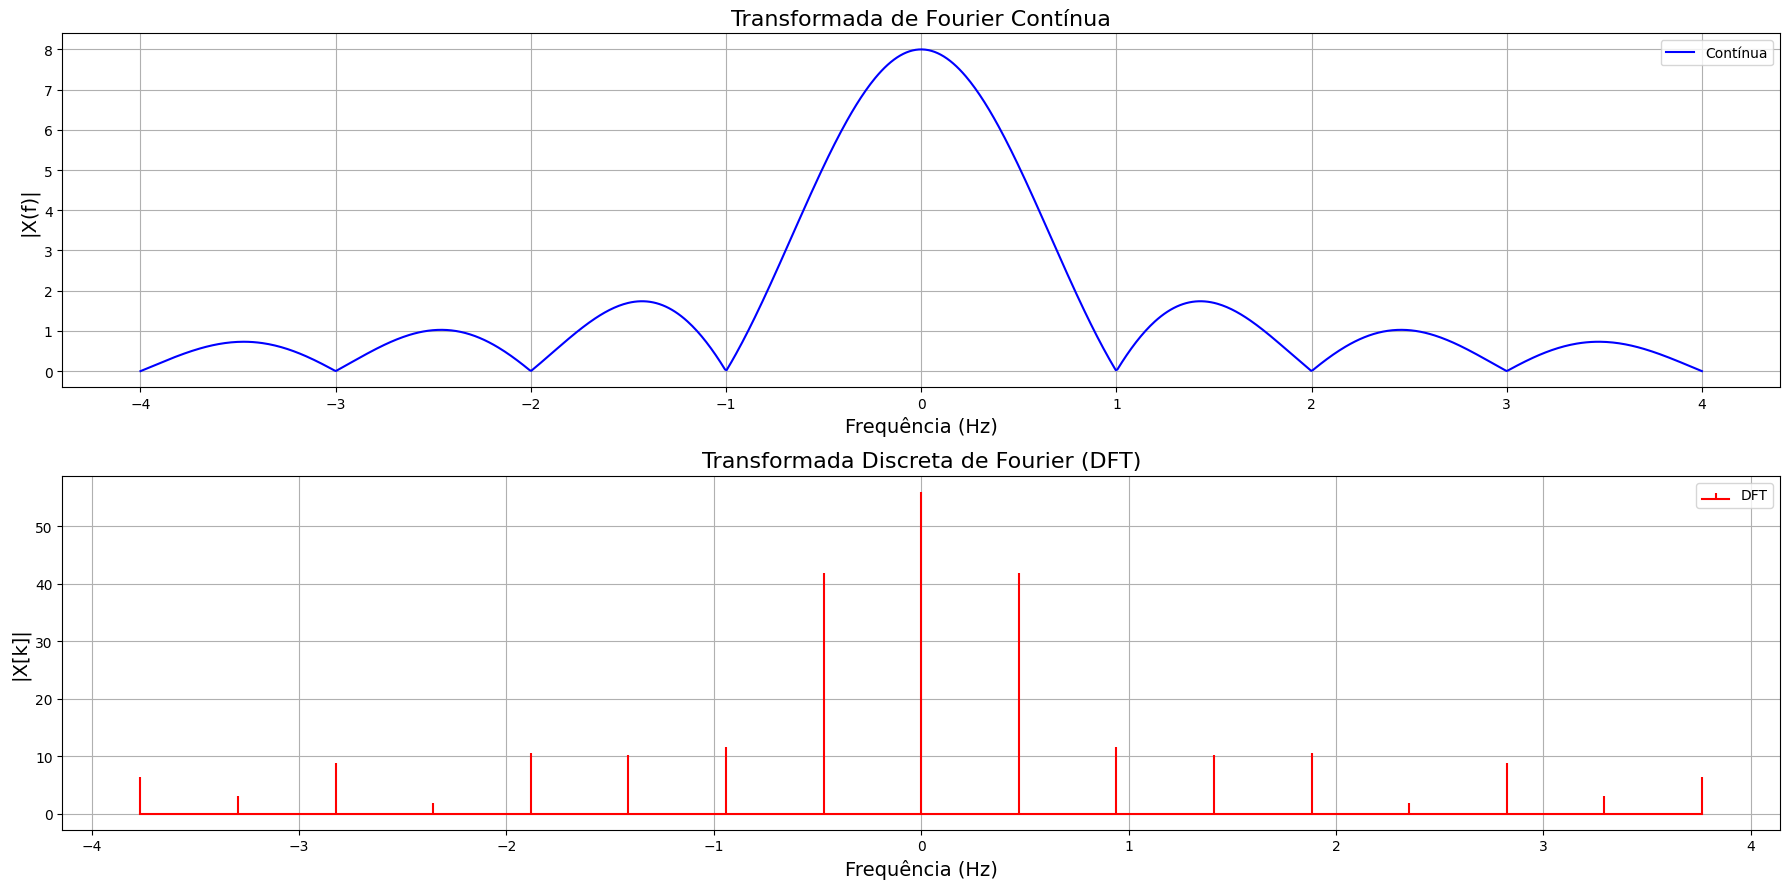

In [12]:
# Resposta da questão 1b

# Taxa de amostragem T = 1/8 s
T = 1/8
fs = 1/T  # Frequência de amostragem

# Tempo de amostragem
t = np.arange(-1, 1 + T, T)

# Amostras do sinal
x_samples = x(t)

# Calcular a DFT das amostras
X_dft = DFT(x_samples)

# Frequências em Hz para a DFT
N = len(x_samples)
freqs_dft = np.fft.fftfreq(N, T)

# Frequências para a Transformada de Fourier contínua
f_cont = np.linspace(-fs/2, fs/2, 1000)
X_continuous = X_cont(f_cont)

# Plotar as Transformadas
plt.figure(figsize=(18, 9))

# Magnitude da Transformada de Fourier contínua
plt.subplot(2, 1, 1)
plt.plot(f_cont, np.abs(X_continuous), label='Contínua', color='blue')
plt.xlabel('Frequência (Hz)', fontsize=14)
plt.ylabel('|X(f)|', fontsize=14)
plt.title('Transformada de Fourier Contínua', fontsize=16)
plt.grid(True)
plt.legend()

# Magnitude da DFT
plt.subplot(2, 1, 2)
plt.stem(freqs_dft, np.abs(X_dft), 'r', markerfmt=" ", basefmt="-r", label='DFT')
plt.xlabel('Frequência (Hz)', fontsize=14)
plt.ylabel('|X[k]|', fontsize=14)
plt.title('Transformada Discreta de Fourier (DFT)', fontsize=16)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Questão 2

Considere um sinal $x\left[n\right]$ com $N = 256$ amostras, onde:
$$
\begin{align}
	x\left[n\right] = \begin{cases}
                               1 & \text{se} ~~ n < 64 \\
															 0 & \text{se} ~~ n \geq 64 \\
                             \end{cases}
\end{align}
$$

Considere agora um filtro passa-baixas ideal $H_1$ com frequência de corte normalizada igual a $\frac{1}{16}$.

## Questão 2a (1.0  ponto)

Filtre o sinal $x\left[n\right]$ com o filtro $H_1$, obtendo o sinal $y\left[n\right]$. Compare o sinal original $x\left[n\right]$ com o sinal obtido $y\left[n\right]$.

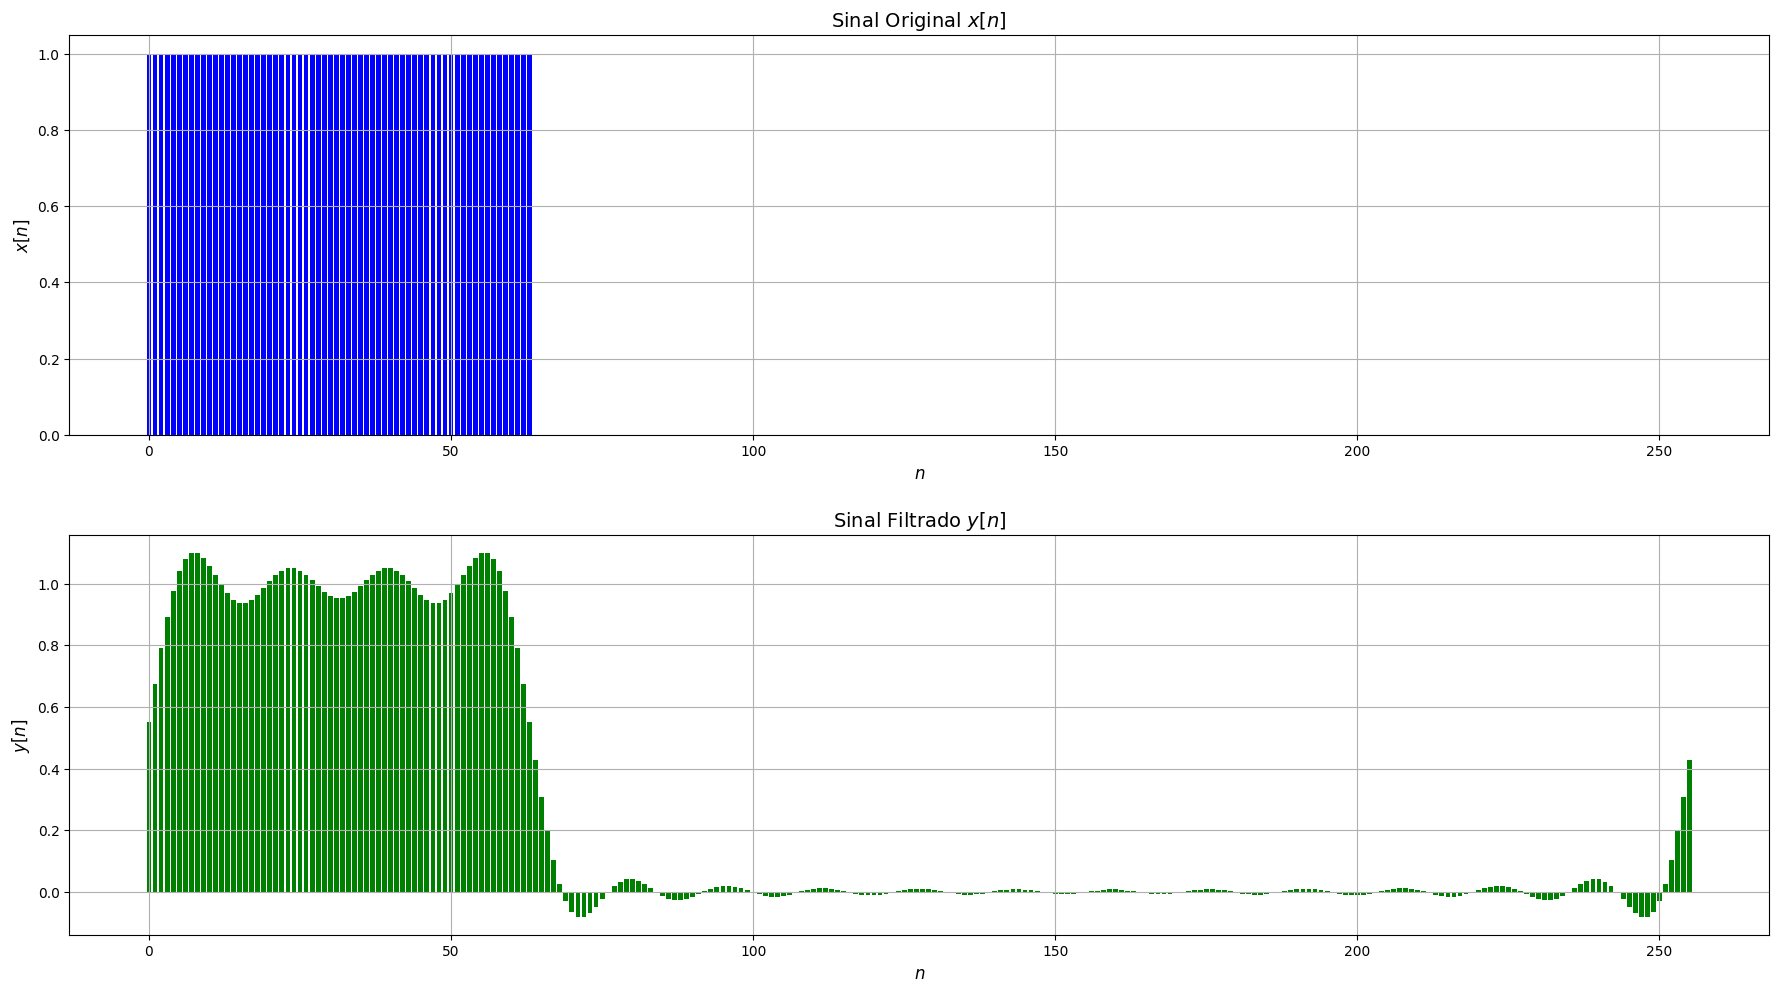

In [13]:
# Resposta da questão 2a

# Definição do sinal x[n]
N = 256
x = np.zeros(N)
x[:64] = 1

# Calcular a DFT do sinal x[n]
X = DFT(x)

# Definição do filtro passa-baixas ideal H_1
cutoff = 1/16
H1 = np.zeros(N)
for k in range(N):
    if k <= cutoff * N or k >= (1 - cutoff) * N:
        H1[k] = 1

# Aplicar o filtro no domínio da frequência
Y = X * H1

# Obter a resposta filtrada no domínio do tempo
y = IDFT(Y)

# Plotar os resultados
plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.bar(np.arange(N), x, color='blue')
plt.title('Sinal Original $x[n]$', fontsize=14)
plt.xlabel('$n$', fontsize=12)
plt.ylabel('$x[n]$', fontsize=12)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.bar(np.arange(N), np.real(y), color='green')
plt.title('Sinal Filtrado $y[n]$', fontsize=14)
plt.xlabel('$n$', fontsize=12)
plt.ylabel('$y[n]$', fontsize=12)
plt.grid(True)

# Ajuste para preencher melhor a tela
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.1, right=0.95, hspace=0.25)

plt.show()



## Questão 2b (1.0 ponto)

Compare o espectro do sinal $x\left[n\right]$ com o espectro do sinal $y\left[n\right]$.

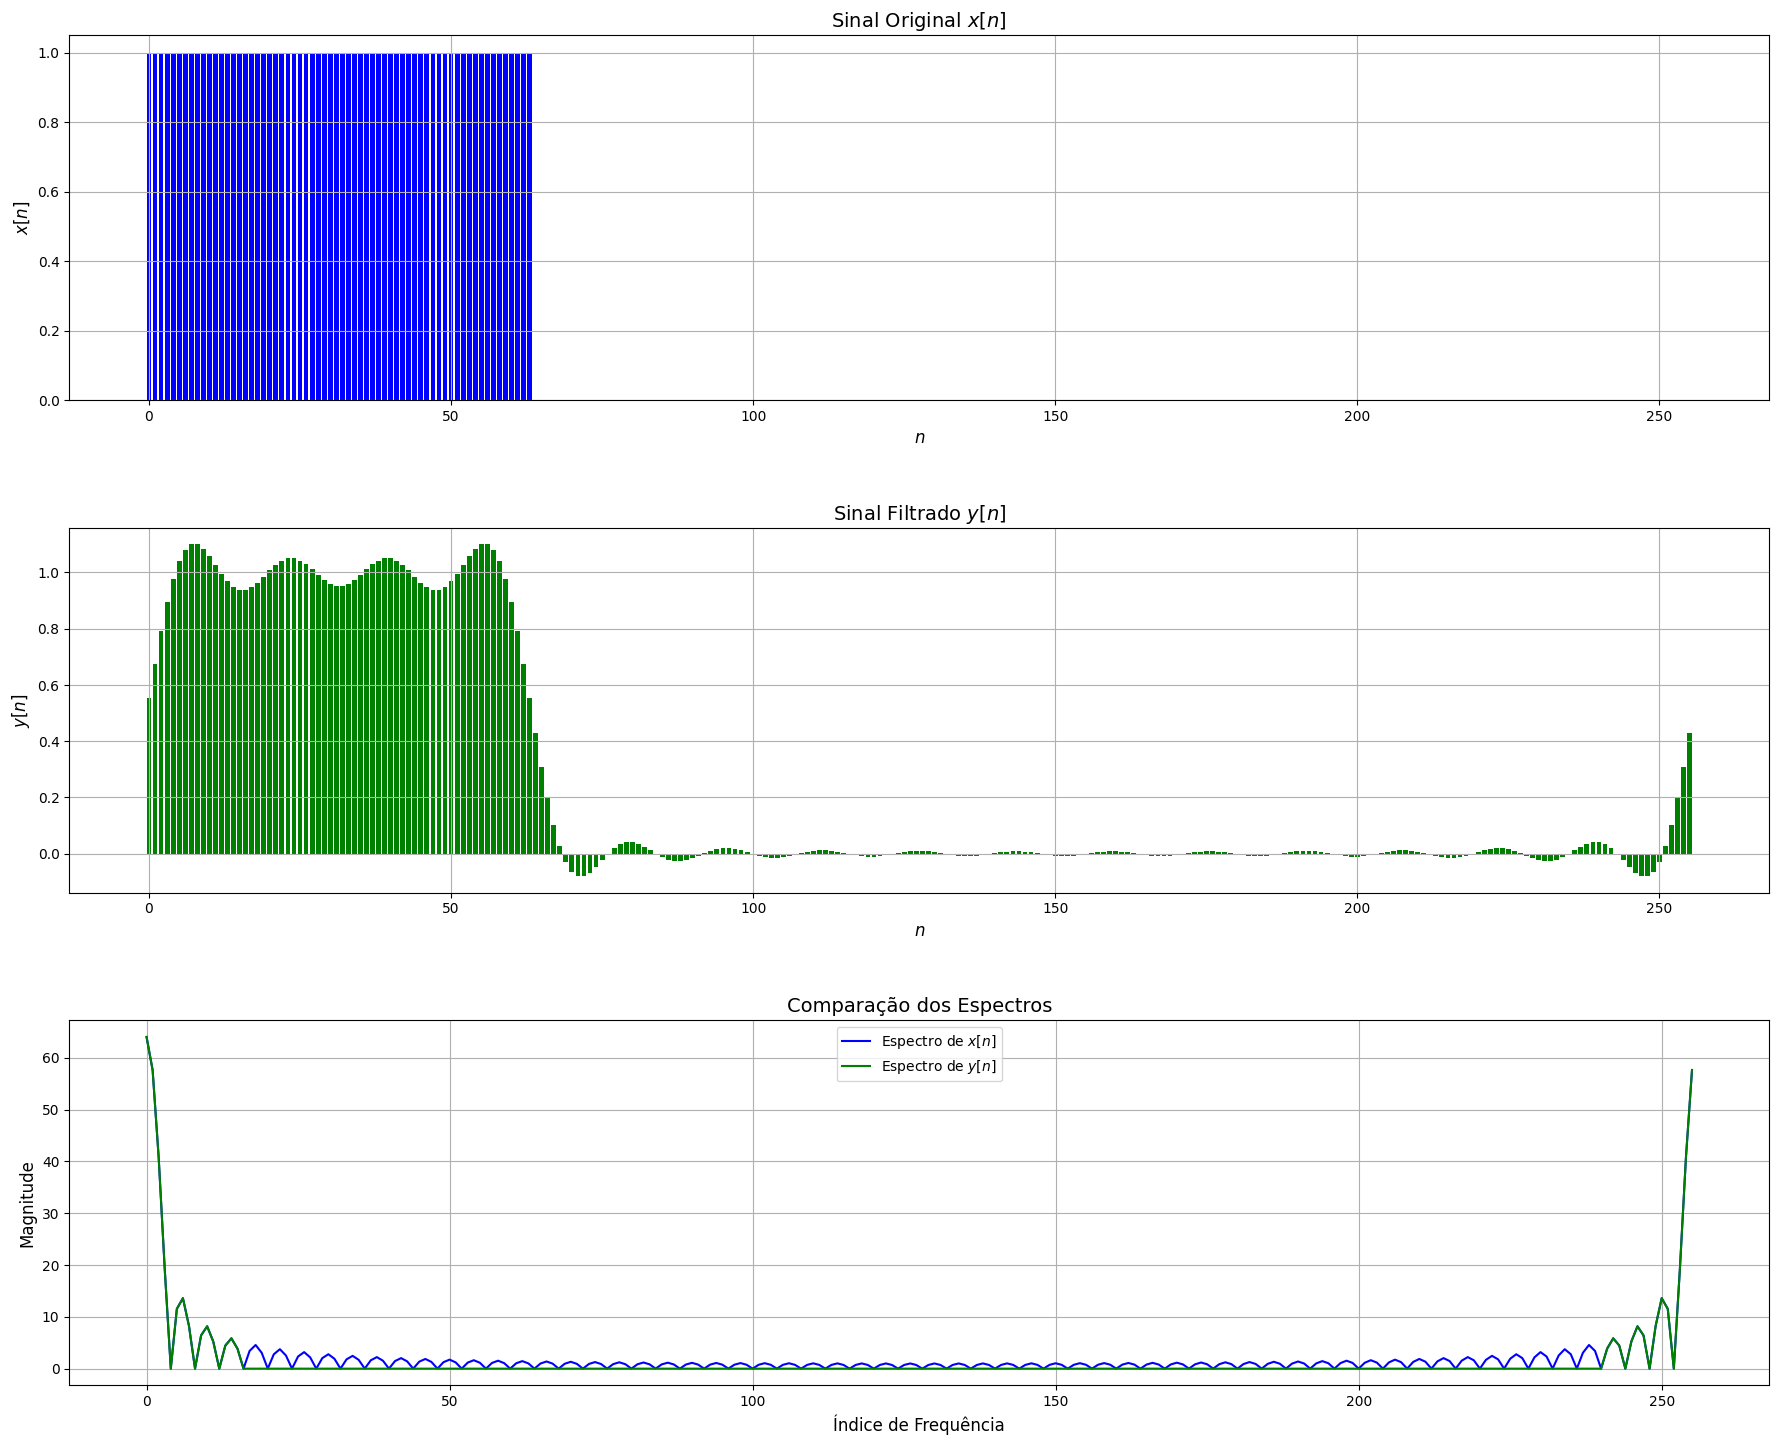

In [14]:
# Resposta da questão 2b

# Definição do sinal x[n]
N = 256
x = np.zeros(N)
x[:64] = 1

# Calcular a DFT do sinal x[n]
X = DFT(x)

# Definição do filtro passa-baixas ideal H_1
cutoff = 1/16
H1 = np.zeros(N)
for k in range(N):
    if k <= cutoff * N or k >= (1 - cutoff) * N:
        H1[k] = 1

# Aplicar o filtro no domínio da frequência
Y = X * H1

# Obter a resposta filtrada no domínio do tempo
y = IDFT(Y)

# Calcular o espectro de magnitude
X_mag = np.abs(X)
Y_mag = np.abs(Y)

# Plotar os resultados
plt.figure(figsize=(20, 15))

plt.subplot(3, 1, 1)
plt.bar(np.arange(N), x, color='blue')
plt.title('Sinal Original $x[n]$', fontsize=14)
plt.xlabel('$n$', fontsize=12)
plt.ylabel('$x[n]$', fontsize=12)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.bar(np.arange(N), np.real(y), color='green')
plt.title('Sinal Filtrado $y[n]$', fontsize=14)
plt.xlabel('$n$', fontsize=12)
plt.ylabel('$y[n]$', fontsize=12)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(np.arange(N), X_mag, label='Espectro de $x[n]$', color='blue')
plt.plot(np.arange(N), Y_mag, label='Espectro de $y[n]$', color='green')
plt.title('Comparação dos Espectros', fontsize=14)
plt.xlabel('Índice de Frequência', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.grid(True)

# Ajuste para preencher melhor a tela
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.1, right=0.95, hspace=0.35)

plt.show()



## Questão 2c (1.0  ponto)

Aplique o filtro $H_1$ no sinal contido no arquivo "noisy_ecg2.mat". Plote o sinal original e o sinal filtrado, bem como seus espectros.


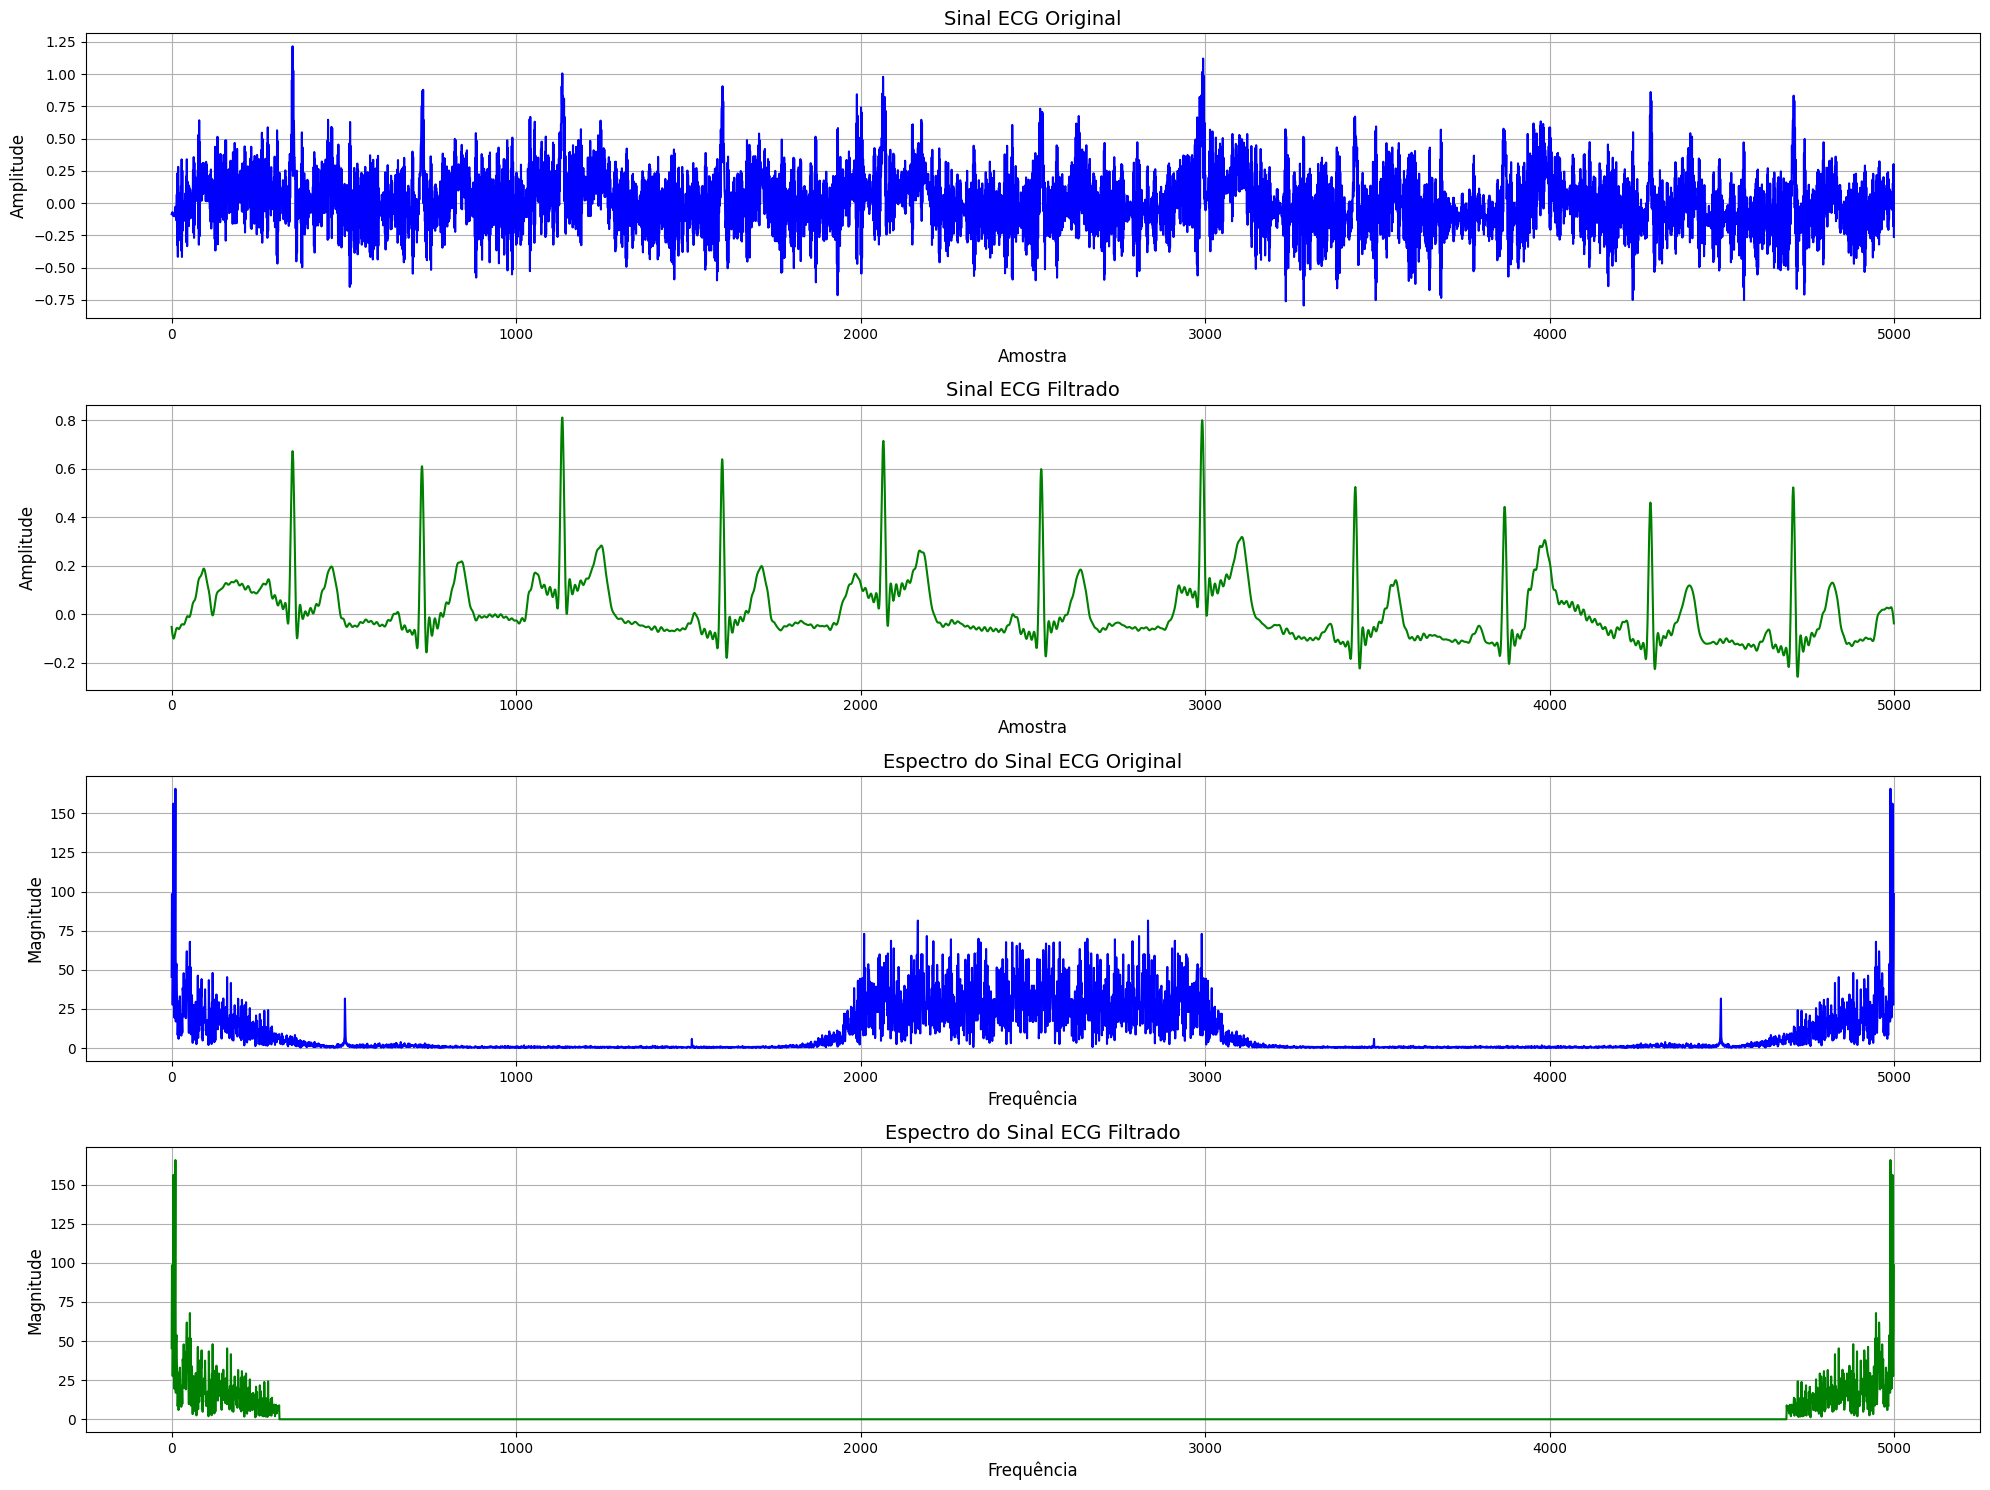

In [15]:
#Resposta da questão 2c

# Carregar o arquivo .mat usando a linha especificada
sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

# Definir o número de amostras
N = len(sinal)

# Calcular a DFT do sinal ECG usando FFT
X_ecg = np.fft.fft(sinal)

# Definição do filtro passa-baixas ideal H_1
cutoff = 1/16
H1 = np.zeros(N)
for k in range(N):
    if k <= cutoff * N or k >= (1 - cutoff) * N:
        H1[k] = 1

# Aplicar o filtro no domínio da frequência
Y_ecg = X_ecg * H1

# Obter a resposta filtrada no domínio do tempo usando IFFT
y_ecg = np.fft.ifft(Y_ecg)

# Calcular o espectro de magnitude
X_ecg_mag = np.abs(X_ecg)
Y_ecg_mag = np.abs(Y_ecg)

# Plotar os resultados
plt.figure(figsize=(20, 15))

plt.subplot(4, 1, 1)
plt.plot(np.arange(N), sinal, color='blue')
plt.title('Sinal ECG Original', fontsize=14)
plt.xlabel('Amostra', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(np.arange(N), np.real(y_ecg), color='green')
plt.title('Sinal ECG Filtrado', fontsize=14)
plt.xlabel('Amostra', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(np.arange(N), X_ecg_mag, color='blue')
plt.title('Espectro do Sinal ECG Original', fontsize=14)
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(np.arange(N), Y_ecg_mag, color='green')
plt.title('Espectro do Sinal ECG Filtrado', fontsize=14)
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()




# Questão 3 (5.0 pontos)

O teclado de um touch-fone usa sinais de diferentes frequências para especificar quais botões foram pressionados. O teclado tem 12 botões, em um arranjo de quatro linhas e três colunas. Quando um botão é pressionado um sinal é gerado pela soma de dois tons senoidais com frequências diferentes. A frequência mais alta indica a coluna da tecla pressionada, enquanto a menor frequência indica a linha da tecla pressionada. As frequências são geradas de acordo com a tabela:

| | | Coluna | |
| :-: | :-: | :-: | :-: |
| Linha | 1209 Hz | 1336 Hz | 1477 Hz |
| 697 Hz | 1 | 2 | 3 |
| 770 Hz | 4 | 5 | 6 |
| 852 Hz | 7 | 8 | 9 |
| 940 Hz | | 0 | |

A frequência de amostragem é de 8192 Hz, e o som de cada tecla dura um segundo. Escreva um programa que decodifique, de forma automática, um sinal composto por um número de telefone gerado com essas características. Teste o seu programa com os sinais encontrados no arquivo "touch_fone.mat".


In [29]:
# Resposta da questão 3

# Carregar os sinais
data = scipy.io.loadmat('touch_fone.mat')
sinal1 = data['x'].ravel()
sinal2 = data['y'].ravel()
sinal3 = data['z'].ravel()

# Frequências de linha e coluna do teclado
linhas_freq = [697, 770, 852, 940]
colunas_freq = [1209, 1336, 1477]
teclas = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [0, 0, 0]  # A última linha com 0s, conforme o teclado especificado
])

# Decodificar os sinais
sample_rate = 8192  # Frequência de amostragem

telefone = [
    decodificar_sinal(sinal1, sample_rate),
    decodificar_sinal(sinal2, sample_rate),
    decodificar_sinal(sinal3, sample_rate)
]

# Mostrar o número de telefone decodificado
print("Número de telefone decodificado:", telefone)


Sinal: [ 0.          0.11320821  0.13160053  0.05963783 -0.01123538 -0.0102997
  0.03403162  0.03456276 -0.04417462 -0.13534179]... Frequências identificadas: [1336.0, 1337.0] -> Mapeadas: [940, 1336]
Sinal: [ 0.          0.12108599  0.13868786  0.05368304 -0.03841507 -0.05647814
 -0.01692337  0.00053076 -0.04124389 -0.08700458]... Frequências identificadas: [697.0, 1209.0] -> Mapeadas: [697, 1209]
Sinal: [ 0.          0.10912461  0.14115735  0.08535305  0.00204845 -0.03720528
 -0.01604379  0.01694128  0.00279391 -0.06352911]... Frequências identificadas: [697.0, 1209.0] -> Mapeadas: [697, 1209]
Número de telefone decodificado: [0, 1, 1]
